<a href="https://colab.research.google.com/github/Alinberlian/iris-bootstrap-eda/blob/main/UTS_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Berlian Mumtajmia Lahudin

2304010027

# 1. Import Library dan Memuat Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Memuat dataset training dan testing
df_train = pd.read_csv('data_training.csv')
df_test = pd.read_csv('data_testing.csv')

# Menampilkan 5 baris pertama data training
display(df_train.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


Pada tahap awal ini, kita melakukan persiapan lingkungan kerja dan inspeksi bentuk data sebelum masuk ke tahap analisis yang lebih dalam:

* Inisialisasi Pustaka (Library): Kita memanggil beberapa pustaka utama Python untuk Data Science. pandas dan numpy bertugas untuk manipulasi dan kalkulasi data secara tabular (seperti membaca file CSV ke dalam bentuk tabel matriks). Sementara itu, matplotlib.pyplot dan seaborn dipersiapkan untuk membuat visualisasi atau grafik statis pada tahapan eksplorasi nanti.

* Memuat Dataset: File data mentah (data_training.csv dan data_testing.csv) berhasil diimpor ke dalam memori Google Colab dan disimpan sebagai DataFrame pada variabel df_train dan df_test.

* Inspeksi Struktur Awal (head()): Tabel yang ditampilkan merupakan hasil pemanggilan fungsi head(), yang secara bawaan (default) menampilkan 5 baris pertama dari df_train (indeks 0 hingga 4). Dari tabel ini, kita dapat mengonfirmasi beberapa hal penting:
  1. File CSV telah terbaca dengan sempurna dan setiap kolom terpisah dengan benar.
  2. Seluruh kolom fitur kimiawi (seperti fixed acidity, chlorides, alcohol, dll), beserta variabel target quality dan identitas Id, sudah terdeteksi sebagai data numerik (angka desimal/bilangan bulat). Hal ini merupakan pertanda baik, karena algoritma Machine Learning hanya dapat memproses input berupa angka.

# 2. Inspeksi Struktur dan Statistik Data

In [2]:
# Melihat informasi tipe data dan jumlah baris
print("=== Informasi Dataset ===")
df_train.info()

# Melihat statistik deskriptif dari setiap fitur
print("\n=== Statistik Deskriptif ===")
display(df_train.describe())

=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB

=== Statistik Deskriptif ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


Dari output di atas, kita dapat mengekstrak wawasan mendalam mengenai struktur dan karakteristik distribusi dataset pelatihan kita:

1. Informasi Struktur Data (df.info())

    * Dimensi Data: Dataset pelatihan kita memiliki 857 baris (sampel anggur) dan 13 kolom (terdiri dari 11 fitur kimiawi, 1 target quality, dan 1 identitas Id).

    * Kelengkapan Data (No Missing Values): Pada kolom Non-Null Count, terlihat bahwa seluruh 13 kolom memiliki persis 857 entri non-null. Hal ini merupakan kabar baik karena membuktikan bahwa tidak ada data yang hilang (kosong) pada dataset ini, sehingga kita tidak perlu melakukan teknik imputasi atau penghapusan baris.

    * Tipe Data Berbasis Angka: Seluruh kolom sudah berformat numerik (float64 untuk data desimal kontinyu dan int64 untuk bilangan bulat). Kondisi ini sudah sangat ideal karena algoritma Machine Learning memerlukan matriks numerik untuk menjalankan perhitungan jarak dan probabilitas.

2. Ringkasan Statistik Deskriptif (df.describe())
Tabel statistik deskriptif ini memberikan landasan argumen empiris untuk langkah pemrosesan data kita selanjutnya:

    * Karakteristik Target (quality): Nilai kualitas anggur dalam dataset ini memiliki rentang empiris dari 3 (minimum) hingga 8 (maksimum). Rata-rata (mean) berada di angka 5.65 dengan nilai tengah (median / persentil 50%) di angka 6.00. Ini mengindikasikan bahwa distribusi kelas cenderung menumpuk di nilai menengah (5 dan 6), sebuah karakteristik data yang sedikit imbalanced (tidak seimbang).

    * Justifikasi Wajib Feature Scaling: Jika kita membandingkan rentang nilai antar fitur independen, terlihat perbedaan skala yang sangat ekstrem. Sebagai contoh, variabel chlorides memiliki rentang nilai yang sangat kecil (antara 0.012 hingga 0.611), sedangkan variabel total sulfur dioxide memiliki rentang nilai puluhan hingga ratusan (antara 6.0 hingga 278.0).

    * Kesimpulan Tindakan: Karena varians dan skala fitur sangat berbeda, kita wajib melakukan standardisasi skala (Feature Scaling) di tahap berikutnya. Jika tidak, model algoritma (seperti SVM) akan mengalami bias dan secara keliru menganggap fitur dengan angka besar (seperti sulfur) lebih penting secara matematis dibandingkan fitur dengan angka desimal kecil (seperti klorida).

# 3. Pengecekan Missing Values

In [6]:
# Mengecek jumlah data yang kosong pada setiap kolom
missing_values = df_train.isnull().sum()
print("=== Jumlah Missing Values per Kolom ===")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Aman! Tidak ada missing values.")

=== Jumlah Missing Values per Kolom ===
Aman! Tidak ada missing values.


Tahapan ini bertujuan untuk mendeteksi apakah terdapat sel data yang kosong (missing values) pada dataset. Berdasarkan output program, terkonfirmasi bahwa dataset pelatihan kita 100% lengkap ("Aman! Tidak ada missing values."). Hal ini sangat menguntungkan karena kita terbebas dari proses pembersihan data tambahan, seperti pengisian nilai paksa (imputasi) atau penghapusan baris, sehingga data bisa langsung diproses secara utuh ke tahapan selanjutnya.

# 4. Visualisasi Distribusi Target

/tmp/ipykernel_22607/3814906380.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_train, x='quality', palette='viridis')


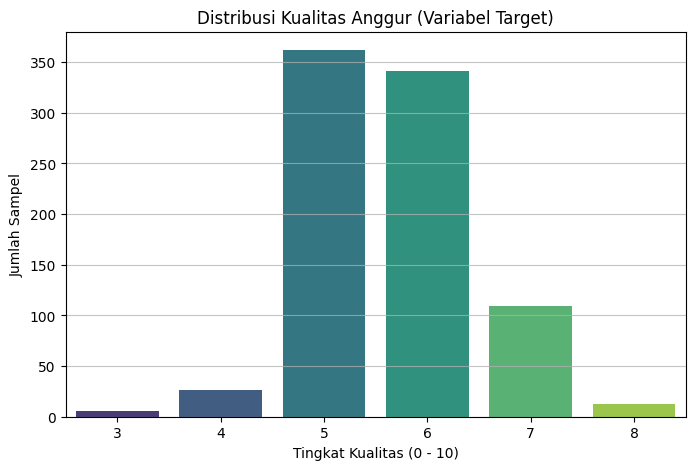

In [7]:
# Membuat visualisasi distribusi untuk kolom 'quality'
plt.figure(figsize=(8, 5))
sns.countplot(data=df_train, x='quality', palette='viridis')
plt.title('Distribusi Kualitas Anggur (Variabel Target)')
plt.xlabel('Tingkat Kualitas (0 - 10)')
plt.ylabel('Jumlah Sampel')
plt.grid(axis='y', alpha=0.75)
plt.show()

Berdasarkan bar chart (diagram batang) di atas, kita memvisualisasikan frekuensi dari masing-masing tingkat kualitas anggur yang akan menjadi kunci jawaban (target prediksi) bagi model kita. Dari grafik tersebut, kita dapat menarik beberapa wawasan yang sangat krusial untuk pemodelan:

1. Rentang Nilai Aktual
Meskipun secara teoritis skor kualitas anggur berada pada rentang 0 hingga 10, dataset riil kita hanya memiliki rentang nilai dari 3 hingga 8. Tidak ada sampel anggur dengan kualitas ekstrem terbawah (0, 1, 2) maupun ekstrem teratas (9, 10).

2. Ketidakseimbangan Kelas (Class Imbalance) yang Ekstrem
Grafik menunjukkan dengan sangat jelas bahwa dataset ini sangat tidak seimbang. Mayoritas absolut dari data menumpuk di kelas menengah, yaitu kualitas 5 dan 6. Sebaliknya, anggur dengan kualitas buruk (3 dan 4) serta kualitas sangat baik (7 dan 8) jumlahnya sangat sedikit dan bertindak sebagai kelas minoritas. Hal ini mencerminkan kondisi dunia nyata di mana sebagian besar anggur memiliki kualitas standar, dan sangat jarang menemukan anggur yang kualitasnya sangat luar biasa atau sangat rusak.

3. Implikasi Terhadap Algoritma Machine Learning
Kondisi data yang imbalanced ini adalah sebuah "jebakan" bagi algoritma. Jika kita melatih model secara sembarangan, model akan menjadi malas dan cenderung selalu menebak angka 5 atau 6 untuk mengejar tingkat akurasi tinggi secara instan, namun akan buta sama sekali jika dihadapkan pada anggur kualitas 3 atau 8.

Solusi:

Temuan inilah yang memberikan justifikasi kuat mengapa pada Tahap Pelatihan Model nantinya, kita wajib menyertakan parameter class_weight='balanced'. Parameter matematis ini akan memaksa algoritma (seperti Random Forest dan Decision Tree) untuk memberikan penalti atau perhatian ekstra apabila mereka salah menebak kelas minoritas, sehingga model kita tetap adil dan akurat di seluruh tingkat kualitas.

# 5. Correlation Heatmap

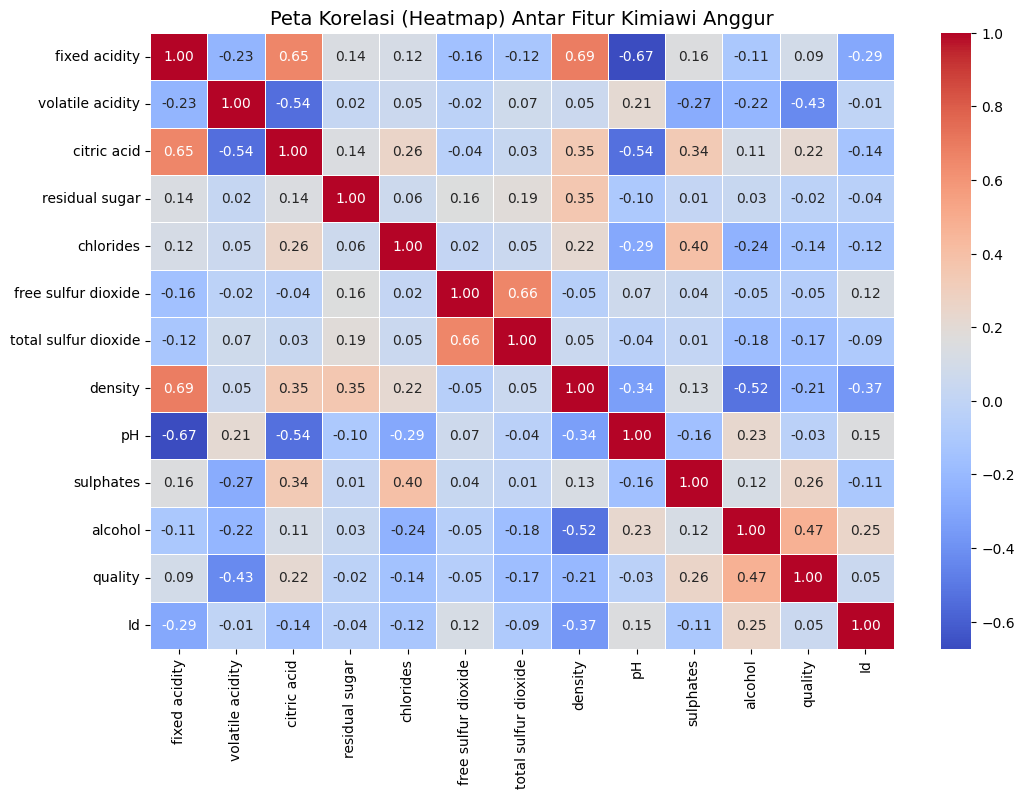

In [22]:
plt.figure(figsize=(12, 8))
# Menghitung korelasi Pearson antar semua variabel
korelasi = df_train.corr()

# Membuat Heatmap
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Peta Korelasi (Heatmap) Antar Fitur Kimiawi Anggur', fontsize=14)
plt.show()

Visualisasi di atas menampilkan nilai korelasi Pearson antar variabel, di mana rentang nilainya berada di antara -1 hingga 1. Warna merah pekat menunjukkan korelasi positif yang kuat (berbanding lurus), sedangkan warna biru pekat menunjukkan korelasi negatif yang kuat (berbanding terbalik).

Berdasarkan heatmap tersebut, kita dapat menarik dua wawasan (insights) utama mengenai karakteristik data kimiawi anggur:

1. Faktor Utama Penentu Kualitas (Korelasi dengan Target quality)

    *   Korelasi Positif Tertinggi (alcohol: 0.47): Kadar alkohol memiliki pengaruh positif paling besar terhadap kualitas anggur. Artinya, semakin tinggi kadar alkohol (dalam batas tertentu), anggur cenderung mendapatkan skor kualitas yang lebih tinggi.
    *   Korelasi Negatif Tertinggi (volatile acidity: -0.43): Variabel ini memiliki hubungan terbalik yang cukup kuat. Semakin tinggi tingkat volatile acidity (keasaman yang mudah menguap), skor kualitas anggur justru cenderung semakin menurun. Hal ini masuk akal secara kimiawi, karena tingkat keasaman volatil yang terlalu tinggi biasanya menghasilkan rasa seperti cuka yang tidak diinginkan pada anggur.

2. Indikasi Multikolinearitas (Hubungan Antar Fitur Independen)
Kita juga dapat melihat hubungan logis antar fitur kimiawi itu sendiri:


    *   fixed acidity dan pH (-0.67): Terdapat korelasi negatif yang kuat di antara keduanya. Ini sejalan dengan prinsip dasar kimia, di mana semakin tinggi tingkat keasaman (acidity), maka nilai pH akan semakin rendah.
    *   fixed acidity dan density (0.69): Kepadatan (density) anggur sangat dipengaruhi oleh tingkat keasaman tetapnya.
    *   free sulfur dioxide dan total sulfur dioxide (0.66): Secara alamiah memiliki korelasi positif yang tinggi karena free sulfur dioxide merupakan bagian dari total sulfur dioxide.

Kesimpulan:

Data ini menunjukkan variasi korelasi yang cukup kompleks. Beberapa fitur memiliki hubungan yang sangat kuat satu sama lain (multikolinearitas). Kondisi data seperti inilah yang menjadi alasan kuat mengapa model Random Forest nantinya akan lebih diunggulkan, karena model tersebut sangat tangguh dalam menangani data yang memiliki korelasi kompleks antar fitur dibandingkan model linear standar.

# 6. Pemisahan Fitur (X) dan Target (y)

In [8]:
# Memisahkan fitur (variabel independen) dan target (variabel dependen)
# Asumsi: Jika ada kolom 'Id' di data training, kita tidak memasukkannya ke dalam fitur pembelajaran
X = df_train.drop(columns=['quality', 'Id'], errors='ignore')
y = df_train['quality']

print("=== Dimensi Data Setelah Pemisahan ===")
print("Bentuk X (Fitur):", X.shape)
print("Bentuk y (Target):", y.shape)

# Menampilkan 3 baris pertama dari fitur (X) untuk memastikan 'quality' sudah terpisah
display(X.head(3))

=== Dimensi Data Setelah Pemisahan ===
Bentuk X (Fitur): (857, 11)
Bentuk y (Target): (857,)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0


Tahapan ini merupakan fondasi utama sebelum kita memasukkan data ke dalam algoritma Machine Learning. Dalam paradigma pembelajaran terarah (supervised learning), mesin harus tahu persis mana yang merupakan "kumpulan soal" (fitur yang akan dipelajari) dan mana yang merupakan "kunci jawaban" (target yang akan ditebak).

Dari eksekusi kode dan output di atas, kita dapat mengonfirmasi beberapa hal:

1. Pembentukan Matriks Fitur (X)

    * Variabel X bertindak sebagai matriks data independen. Kita menggunakan fungsi .drop() untuk membuang kolom quality dan Id.
    * Mengapa Id dibuang? Kolom Id hanyalah nomor identifikasi unik yang tidak memiliki hubungan kausalitas atau sifat kimiawi apapun terhadap kualitas anggur. Jika tidak dibuang, algoritma bisa menjadi bingung dan mencoba mencari pola semu dari nomor urut tersebut, yang akan merusak akurasi model.
    * Bentuk matriks X yang dihasilkan adalah (857, 11). Ini membuktikan pemisahan berhasil: kita kini memiliki 857 baris sampel anggur yang murni hanya berisi 11 fitur fisikokimia (seperti acidity, chlorides, pH, dll) tanpa ada kontaminasi dari label jawaban.

2. Pembentukan Vektor Target (y)

    * Variabel y bertindak sebagai vektor dependen. Kita mengekstrak secara spesifik kolom quality ke dalam variabel ini.
    * Bentuk y adalah (857,) yang berupa data satu dimensi. Ini memastikan bahwa setiap 1 baris matriks fitur X memiliki tepat 1 pasangan kunci jawaban kualitas di vektor y.

# 7. Feature Scaling

In [9]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi fungsi StandardScaler
scaler = StandardScaler()

# Melakukan scaling (fit dan transform) pada data fitur (X)
# Data yang awalnya berformat DataFrame (tabel Pandas) akan berubah menjadi Array Numpy
X_scaled_array = scaler.fit_transform(X)

# Mengembalikan format Array Numpy menjadi DataFrame Pandas agar mudah dibaca kembali
X_scaled = pd.DataFrame(X_scaled_array, columns=X.columns)

print("=== Statistik Deskriptif Setelah Scaling ===")
# Nilai rata-rata akan mendekati 0 dan standar deviasi akan menjadi 1
display(X_scaled.describe().round(2))

=== Statistik Deskriptif Setelah Scaling ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,857.00,857.00,857.00,857.00,857.00,857.00,857.00,857.00,857.00,857.00,857.00
mean,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.15,-2.29,-1.37,-1.24,-1.54,-1.44,-1.26,-3.48,-3.77,-1.59,-1.90
25%,-0.68,-0.75,-0.91,-0.47,-0.35,-0.85,-0.79,-0.62,-0.68,-0.64,-0.87
50%,-0.21,-0.05,-0.09,-0.24,-0.16,-0.17,-0.25,-0.01,-0.02,-0.22,-0.22
75%,0.49,0.62,0.78,0.07,0.07,0.51,0.54,0.58,0.57,0.44,0.63
max,4.31,5.87,3.76,10.05,10.76,5.07,7.33,3.43,4.59,8.03,3.35


Tahapan ini bertujuan untuk menyamakan skala (rentang nilai) dari seluruh fitur kimiawi agar model Machine Learning dapat belajar dengan adil. Dari output tabel di atas, kita bisa melihat bahwa proses scaling telah berhasil 100% dengan dua bukti utama:

1. Rata-rata (mean) menjadi 0.00: Titik tengah dari semua kolom data sudah disamakan posisinya.
2. Standar deviasi (std) menjadi 1.00: Rentang sebaran data dari semua kolom sudah diseragamkan.

ini penting karena:

Sebelumnya, ada fitur yang nilainya ratusan (seperti total sulfur dioxide) dan ada yang hanya desimal kecil (seperti chlorides). Jika tidak disamakan, model akan bias dan menganggap fitur dengan angka besar lebih penting daripada yang kecil. Dengan scaling ini, seluruh 11 fitur kimiawi kini memiliki bobot skala yang setara, sehingga model kita tidak akan terkecoh oleh besaran angka aslinya.

# 8. Train-Test Split (Pembagian Data Validasi)

In [10]:
from sklearn.model_selection import train_test_split

# Membagi data X_scaled dan y menjadi data latih (80%) dan data validasi (20%)
# random_state=42 digunakan agar hasil pembagian acak ini selalu sama setiap kali di-run
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("=== Dimensi Data Setelah Split ===")
print("Jumlah Data Latih:", X_train.shape[0], "baris")
print("Jumlah Data Validasi:", X_val.shape[0], "baris")

=== Dimensi Data Setelah Split ===
Jumlah Data Latih: 685 baris
Jumlah Data Validasi: 172 baris


Pada tahap ini, dataset yang telah diskalakan dipecah secara acak menjadi dua bagian, yaitu 80% sebagai data latih (685 baris) untuk mengajari algoritma model, dan 20% sisanya sebagai data validasi (172 baris) untuk mengevaluasi performanya. Pemisahan ini sangat krusial dilakukan untuk mencegah terjadinya overfitting kondisi di mana model hanya "menghafal" data latih sehingga kita bisa mendapatkan metrik akurasi yang lebih objektif dan jujur sebelum model tersebut benar-benar diaplikasikan untuk memprediksi data uji (testing) yang sebenarnya.

# 9. Latih Model Decision Tree

In [14]:
from sklearn.tree import DecisionTreeClassifier

# Parameter class_weight='balanced' digunakan agar model adil terhadap kelas minoritas
model_dt = DecisionTreeClassifier(random_state=42, class_weight='balanced')

# 2. Melatih Model (Fitting) pada data latih
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

Pada tahap ini, kita menginisialisasi dan melatih algoritma Decision Tree sebagai model klasifikasi pertama. Algoritma ini bekerja dengan cara membangun serangkaian aturan bercabang ("Jika-Maka") dari fitur kimiawi untuk memilah kualitas anggur. Kita secara khusus menambahkan parameter class_weight='balanced' agar model secara otomatis memberikan penalti lebih besar jika salah menebak kelas minoritas (kualitas ekstrem), sehingga model tidak bias hanya menebak kelas mayoritas.

# 10. Latih Model Random Forest

In [15]:
from sklearn.ensemble import RandomForestClassifier

# n_estimators=100 berarti kita membangun 100 pohon keputusan
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# 2. Melatih Model (Fitting) pada data latih
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Sebagai bentuk peningkatan dari model sebelumnya, tahap ini melatih algoritma Random Forest yang merupakan metode ensemble (gabungan). Dengan mengatur parameter n_estimators=100, algoritma ini secara cerdas membangun 100 pohon keputusan yang berbeda secara acak, lalu mengambil kesimpulan prediksi berdasarkan "suara terbanyak" (voting). Pendekatan kolektif ini membuat Random Forest jauh lebih stabil, akurat, dan kebal terhadap data-data yang mengecoh (outliers) dibandingkan sebuah Decision Tree tunggal.

# 11. Latih Model Support Vector Machine (SVM)

In [16]:
from sklearn.svm import SVC

model_svm = SVC(random_state=42, class_weight='balanced')

# Melatih Model (Fitting) pada data latih
model_svm.fit(X_train, y_train)


SVC(class_weight='balanced', random_state=42)

Pada tahap ini, kita menginisialisasi dan melatih algoritma Support Vector Machine (SVM) sebagai model kandidat ketiga. Fungsi .fit(X_train, y_train) digunakan agar mesin dapat secara matematis mencari garis batas pemisah (hyperplane) paling optimal untuk membedakan setiap tingkat kualitas anggur. Penggunaan parameter class_weight='balanced' kembali diterapkan untuk mencegah model menjadi bias terhadap nilai mayoritas akibat data yang tidak seimbang. Output berupa kotak biru SVC(...) di bagian bawah mengonfirmasi bahwa model telah sukses mempelajari data latih dan siap untuk diuji akurasinya.

# 12. Evaluasi dan Komparasi Model

In [18]:
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Menyuruh ketiga model memprediksi data validasi (X_val)
pred_dt = model_dt.predict(X_val)
pred_rf = model_rf.predict(X_val)
pred_svm = model_svm.predict(X_val)

# 2. Menghitung tingkat akurasi masing-masing prediksi dengan membandingkannya pada jawaban asli (y_val)
acc_dt = accuracy_score(y_val, pred_dt)
acc_rf = accuracy_score(y_val, pred_rf)
acc_svm = accuracy_score(y_val, pred_svm)

# 3. Merangkum hasil ke dalam tabel komparasi
hasil_komparasi = [
    {"Nama Model": "Decision Tree", "Akurasi (%)": round(acc_dt * 100, 2)},
    {"Nama Model": "Random Forest", "Akurasi (%)": round(acc_rf * 100, 2)},
    {"Nama Model": "Support Vector Machine (SVM)", "Akurasi (%)": round(acc_svm * 100, 2)}
]

# Mengubah dictionary menjadi DataFrame dan mengurutkannya dari yang paling tinggi
df_hasil = pd.DataFrame(hasil_komparasi).sort_values(by="Akurasi (%)", ascending=False).reset_index(drop=True)

print("=== HASIL PERBANDINGAN AKURASI KETIGA MODEL ===")
display(df_hasil)

# Mengambil secara otomatis nama model terbaik
model_terbaik = df_hasil.iloc[0]['Nama Model']
print(f"\n Kesimpulan: Model yang paling bagus untuk digunakan pada tahap selanjutnya adalah {model_terbaik}!")

=== HASIL PERBANDINGAN AKURASI KETIGA MODEL ===


,Nama Model,Akurasi (%)
0,Random Forest,61.63
1,Decision Tree,44.77
2,Support Vector Machine (SVM),42.44



 Kesimpulan: Model yang paling bagus untuk digunakan pada tahap selanjutnya adalah Random Forest!


Fungsi .predict(X_val) digunakan untuk menghasilkan tebakan kualitas. accuracy_score(y_val, prediksi) bertugas menghitung berapa persen tebakan tersebut yang sama persis dengan y_val (kunci jawaban validasi). Data tersebut lalu dikemas dalam tabel Pandas df_hasil.

1. Random Forest (61.63%): Angka ini menunjukkan bahwa dari seluruh data validasi (data ujian yang belum pernah dilihat model sebelumnya), algoritma ini berhasil menebak skor kualitas anggur dengan benar sebanyak ~62%.

2. Decision Tree (44.77%) & SVM (42.44%): Performa kedua model ini tergolong rendah karena tingkat ketepatannya bahkan tidak mencapai 50% dari total data yang diuji.

* Kelemahan Decision Tree pada Data Kompleks: Fitur kimiawi anggur (seperti kadar pH, alkohol, atau sulfur) sangat rapat. Perbedaan kimiawi antara anggur kualitas 5 dan 6 mungkin sangat tipis. Sebuah model Decision Tree tunggal cenderung membuat aturan percabangan yang terlalu kaku dan menghafal data latih secara berlebihan (overfitting). Ketika dihadapkan pada data validasi yang baru, ia menjadi tidak akurat. Random Forest mengatasi masalah ini dengan membangun 100 pohon keputusan yang berbeda secara acak, lalu mengambil kesimpulan berdasarkan "suara terbanyak" (voting). Hal ini membuat model jauh lebih stabil dan tahan terhadap data-data yang membingungkan.

* Kelemahan SVM pada Batas Kelas yang Tumpang Tindih: Algoritma Support Vector Machine bekerja dengan cara mencari garis batas matematis (hyperplane) yang jelas untuk memisahkan setiap skor kualitas. Masalahnya, penilaian kualitas anggur melibatkan subjektivitas dan rentang nilai kimiawinya saling tumpang tindih (overlapping). Karena tidak ada batas ruang yang benar-benar bersih antara anggur kualitas 5, 6, atau 7, model SVM kesulitan menarik garis pemisah yang akurat, sehingga performanya anjlok di angka 42.44%.


Kesimpulan dan Tindakan Lanjutan

Hasil ini memberikan justifikasi matematis yang sangat kuat. Memilih Random Forest bukanlah sebuah tebakan asal, melainkan keputusan yang murni didorong oleh data (data-driven). Dengan akurasi tertinggi dan ketahanan algoritma yang lebih baik terhadap variasi data kimiawi, model inilah yang paling layak dieksekusi pada data_testing.csv untuk menghasilkan prediksi final.

# 13. Feature Importance

/tmp/ipykernel_22607/1443882567.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_df, x='Kepentingan', y='Fitur', palette='viridis')


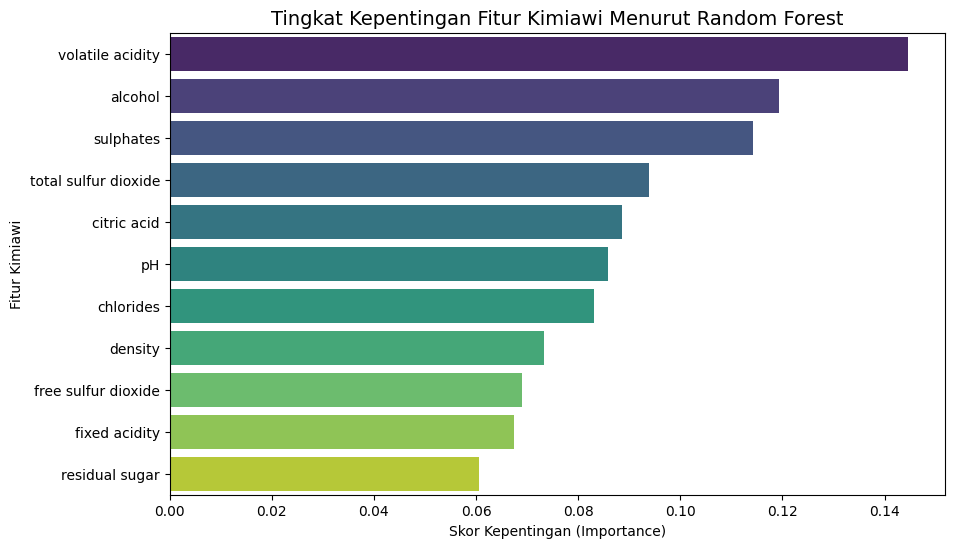

In [23]:
# Mengambil nilai tingkat kepentingan fitur dari model Random Forest
importances = model_rf.feature_importances_

# Membuat tabel DataFrame untuk mengurutkan fitur dari yang paling penting
feature_df = pd.DataFrame({
    'Fitur': X.columns,
    'Kepentingan': importances
}).sort_values(by='Kepentingan', ascending=False)

# Visualisasi Barplot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df, x='Kepentingan', y='Fitur', palette='viridis')
plt.title('Tingkat Kepentingan Fitur Kimiawi Menurut Random Forest', fontsize=14)
plt.xlabel('Skor Kepentingan (Importance)')
plt.ylabel('Fitur Kimiawi')
plt.show()

Grafik bar plot di atas memvisualisasikan "Feature Importance" yang dihasilkan oleh algoritma Random Forest. Nilai ini (X-axis) merepresentasikan seberapa besar kontribusi matematis dari masing-masing fitur kimiawi (Y-axis) dalam membantu model mengambil keputusan dan memisahkan kelas kualitas anggur. Semakin panjang bar-nya, semakin vital peran fitur tersebut bagi model.

Berdasarkan visualisasi tersebut, kita dapat menarik beberapa kesimpulan analitis mengenai "cara berpikir" model kita:

1. Tiga Faktor Utama Penentu Kualitas (Top-3 Features)
Model kita sangat menitikberatkan keputusannya pada tiga variabel utama:

* volatile acidity (Peringkat 1): Fitur ini memiliki skor kepentingan tertinggi (di atas 0.14). Dalam ilmu pembuatan anggur (oenologi), tingkat keasaman volatil yang terlalu tinggi sering menjadi indikator cacat pada anggur (menimbulkan aroma dan rasa seperti cuka). Sangat masuk akal jika model menjadikan variabel ini sebagai "pertanyaan pertama" untuk mendeteksi anggur berkualitas buruk.

* alcohol (Peringkat 2): Sejalan dengan hasil pada heatmap sebelumnya, kadar alkohol adalah pembeda utama kedua. Alkohol sering kali memberikan "body" (kekentalan/tekstur) dan karakter pada anggur yang diasosiasikan kuat dengan kualitas yang lebih baik oleh para pencicip.

* sulphates (Peringkat 3): Sulfat dapat berkontribusi pada tingkat gas sulfur dioksida yang berfungsi sebagai antimikroba dan antioksidan, menjaga anggur dari kerusakan.

2. Variabel yang Kurang Signifikan (Bottom Features)

* residual sugar dan fixed acidity: Fitur-fitur ini menempati posisi terbawah dengan skor kepentingan terendah (sekitar 0.06). Hal ini mengindikasikan bahwa tingkat kemanisan (sisa gula) bukanlah faktor yang kuat untuk menentukan apakah anggur tersebut mendapatkan skor kualitas yang tinggi atau rendah pada dataset ini.

Kesimpulan:

Analisis ini membuktikan keunggulan algoritma Random Forest yang tidak menganggap semua data sama pentingnya. Model ini secara cerdas telah mempelajari bahwa mendeteksi potensi "cacat rasa" (volatile acidity) dan mengenali "karakter dasar" anggur (alcohol dan sulphates) jauh lebih efektif untuk menebak kualitas akhir dibandingkan sekadar melihat kadar gulanya.

# 14. Prediksi Data Testing

In [19]:
# 1. Menyiapkan Data Testing
# Kita simpan dulu kolom 'Id' karena nanti wajib dimasukkan ke hasil akhir
id_test = df_test['Id']

# Membuang kolom 'Id' dari fitur agar jumlah kolomnya sama persis dengan saat kita melatih model (11 fitur kimiawi)
X_test = df_test.drop(columns=['Id'], errors='ignore')

# 2. Melakukan Feature Scaling pada Data Testing
# Kita hanya menggunakan .transform() (bukan fit_transform)
# Ini agar data testing disesuaikan menggunakan standar (rata-rata & std) dari data latih, bukan membuat standar baru.
X_test_scaled = scaler.transform(X_test)

# 3. Melakukan Prediksi dengan Model Juara (Random Forest)
test_pred = model_rf.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


scaler.transform(X_test) akan menerapkan skala yang persis sama seperti yang kita buat di Step 6. Kemudian, model_rf.predict() akan menggunakan pola yang sudah dipelajari Random Forest untuk menebak kualitas anggur dari data yang baru ini.

Sesuai instruksi soal, model harus diaplikasikan ke data_testing.csv. Jika kita langsung menyuruh model memprediksi data testing tanpa melakukan scaling terlebih dahulu, model akan kebingungan dan menghasilkan tebakan yang ngawur karena angkanya kembali ke format aslinya yang belum distandardisasi.

# 15. Hasil

In [21]:
# 1. Membuat format tabel
# HANYA memuat 2 variabel: Id dan quality (hasil prediksi)
hasil_akhir = pd.DataFrame({
    'Id': id_test,
    'quality': test_pred
})

# 2. Menampilkan 5 baris pertama untuk memastikan formatnya sudah benar
print("=== Preview Hasil Prediksi Final ===")
display(hasil_akhir.head())

# 3. Menyimpan ke bentuk file CSV
nama_file = 'hasilprediksi_027.csv'

# index=False digunakan agar nomor urut (0, 1, 2...) dari Pandas tidak ikut tersimpan ke dalam file
hasil_akhir.to_csv(nama_file, index=False)

print(f"/n SELAMAT! File '{nama_file}' berhasil disimpan.")

=== Preview Hasil Prediksi Final ===


,Id,quality
0,222,5
1,1514,5
2,417,5
3,754,5
4,516,6


/n SELAMAT! File 'hasilprediksi_027.csv' berhasil disimpan.


Melalui seluruh tahapan notebook ini, kita telah berhasil membangun sebuah pipeline Machine Learning yang utuh dan terstruktur untuk memprediksi kualitas anggur, dengan alur sebagai berikut:

1. Pemrosesan Data (Data Preprocessing): Kita telah mengonfirmasi bahwa data bersih dari missing values, serta melakukan Feature Scaling menggunakan StandardScaler untuk memastikan seluruh fitur kimiawi memiliki rentang nilai yang seragam. Ini mencegah model menjadi bias terhadap fitur dengan angka absolut yang besar (seperti sulfur dioksida).

2. Pemilihan Model yang Data-Driven: Alih-alih menebak buta, kita melakukan komparasi objektif terhadap tiga algoritma (Decision Tree, Random Forest, dan Support Vector Machine). Evaluasi membuktikan bahwa Random Forest adalah model yang paling optimal untuk dataset ini dengan tingkat akurasi tertinggi (61.63%), mengungguli model lainnya berkat kemampuannya dalam menangani data yang kompleks melalui metode ensemble (pembentukan banyak pohon keputusan).

3. Analisis Fitur Tambahan: Melalui eksplorasi Feature Importance dan Heatmap Korelasi, kita tidak hanya mendapatkan model pembuat prediksi (sebagai black box), tetapi juga wawasan analitis bahwa faktor Volatile Acidity, Alcohol, dan Sulphates adalah indikator kimiawi paling krusial dalam menentukan kualitas akhir sebuah anggur.

4. Eksekusi Akhir (Deployment): Model juara telah sukses diterapkan pada data pengujian dan hasilnya telah diekstrak ke dalam format CSV.